In [50]:
import numpy as np
import pandas as pd
from patsy import dmatrices
from sklearn import metrics
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

Z treści przed punktami

In [51]:
df = pd.read_csv("Auto.csv")
df['origin'] = df['origin'].astype('category')
df.head(n=5)

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


Tworzenie funkcji pod zadanie a)


In [52]:
def linearRegression(model_formula, train, valid, print_result=False):      
      
    y_train, X_train = dmatrices(model_formula, data=train, return_type='dataframe')   
    y_valid, X_valid = dmatrices(model_formula, data=valid, return_type='dataframe')

    model = sm.OLS(y_train, X_train) 
    result = model.fit() 

    y_train_pred = result.predict(X_train)
    y_valid_pred = result.predict(X_valid)

    mse_train = metrics.mean_squared_error(y_train, y_train_pred)
    mse_test = metrics.mean_squared_error(y_valid, y_valid_pred)
    generalization_error = mse_test - mse_train

    if print_result: 
        print(f"Model: {model_formula}")
        print(f"MSE Train: {mse_train:.3f}")
        print(f"MSE Test: {mse_test:.3f}")
        print(f"Generalization Error: {generalization_error:.3f}")
        print()

    return result

Dzielenie modelu na częśc testową i na część treningową

In [53]:
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df = df.dropna(subset=['horsepower'])
df = df.drop(columns=['name'])

mask = np.random.rand(len(df)) < 0.8
train = df[mask]
valid = df[~mask]

linearRegression('mpg ~ horsepower', train, valid).summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.603
Model:                            OLS   Adj. R-squared:                  0.602
Method:                 Least Squares   F-statistic:                     473.6
Date:                Thu, 06 Nov 2025   Prob (F-statistic):           1.58e-64
Time:                        17:28:03   Log-Likelihood:                -940.50
No. Observations:                 314   AIC:                             1885.
Df Residuals:                     312   BIC:                             1892.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     39.3984      0.787     50.057      0.000      37.850      40.947
horsepower    -0.1531      0.007    -21.763      0.000      -0.167      -0.139
==============================================================================
Omnibus:                        8.701   Durbin-Watson:                   1.011
Prob(Omnibus):                  0.013   Jarque-Bera (JB):                8.679
Skew:                           0.400   Prob(JB):                       0.0130
Kurtosis:                       3.151   Cond. No.                         322.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Zadanie b)
correlation matrix
scatter matrix

                   mpg  cylinders  displacement  horsepower    weight  \
mpg           1.000000  -0.777618     -0.805127   -0.778427 -0.832244   
cylinders    -0.777618   1.000000      0.950823    0.842983  0.897527   
displacement -0.805127   0.950823      1.000000    0.897257  0.932994   
horsepower   -0.778427   0.842983      0.897257    1.000000  0.864538   
weight       -0.832244   0.897527      0.932994    0.864538  1.000000   
acceleration  0.423329  -0.504683     -0.543800   -0.689196 -0.416839   
year          0.580541  -0.345647     -0.369855   -0.416361 -0.309120   
origin        0.565209  -0.568932     -0.614535   -0.455171 -0.585005   

              acceleration      year    origin  
mpg               0.423329  0.580541  0.565209  
cylinders        -0.504683 -0.345647 -0.568932  
displacement     -0.543800 -0.369855 -0.614535  
horsepower       -0.689196 -0.416361 -0.455171  
weight           -0.416839 -0.309120 -0.585005  
acceleration      1.000000  0.290316  0.212746  

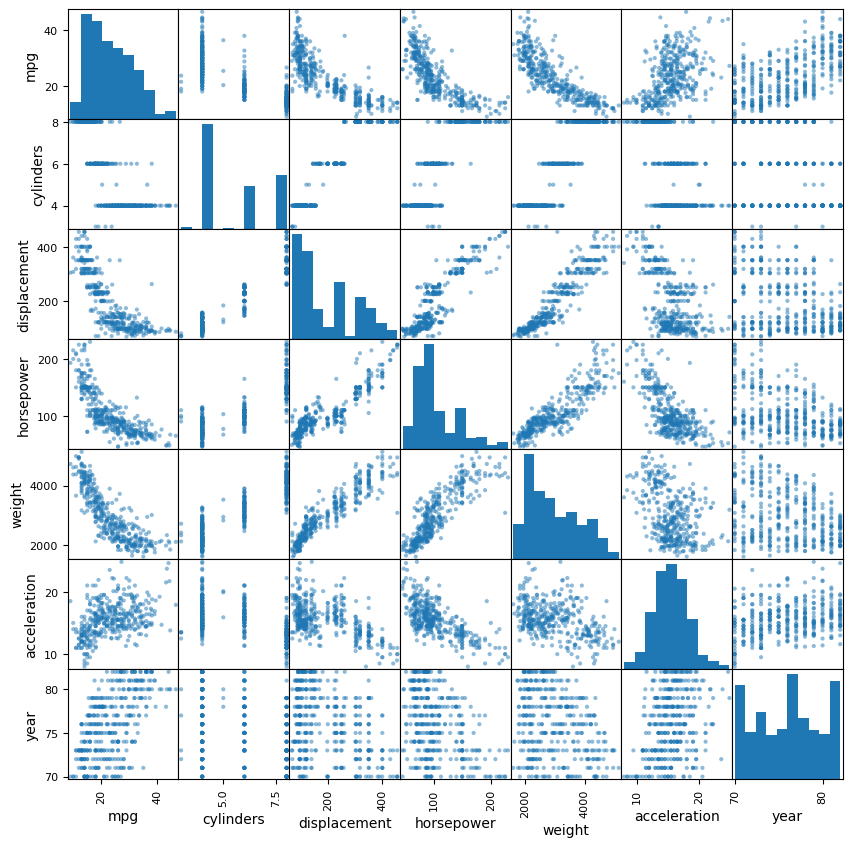

In [60]:
print(df.corr())
axis = pd.plotting.scatter_matrix(df, figsize=(10,10))

Zadaeni c)

Definowanie modeli

In [61]:
models = [
    'mpg ~ cylinders',
    'mpg ~ displacement',
    'mpg ~ horsepower',
    'mpg ~ weight',
    'mpg ~ acceleration',
    'mpg ~ year',

    'mpg ~ horsepower + weight',
    'mpg ~ horsepower + weight + year',
    'mpg ~ displacement + weight + year',
    'mpg ~ cylinders + horsepower + weight',
    'mpg ~ cylinders + horsepower + weight + acceleration + year',

    'mpg ~ horsepower + I(horsepower**2)',
    'mpg ~ weight + I(weight**2)',
    'mpg ~ displacement + I(displacement**2)',
    'mpg ~ I(np.log(weight))',
    'mpg ~ I(np.log(horsepower))',

    'mpg ~ horsepower * weight',
    'mpg ~ horsepower * year',
    'mpg ~ weight * year',
    'mpg ~ cylinders * weight',
    'mpg ~ horsepower * acceleration',

    'mpg ~ I(np.log(weight)) * year',
    'mpg ~ horsepower + I(horsepower**2) + weight',
    'mpg ~ horsepower * I(weight**2)',
    'mpg ~ I(np.sqrt(horsepower)) * weight',

    'mpg ~ cylinders + displacement + horsepower + weight + acceleration + year',

    'mpg ~ cylinders + displacement + horsepower + weight + acceleration + year + I(horsepower**2) + I(weight**2) + I(year**2)'
]

Towrzenie modeli z ich definicji

In [ ]:
results = []

for model in models:
    result = linearRegression(model, train, valid)
    results.append(result)

[<statsmodels.regression.linear_model.RegressionResultsWrapper object at 0xffff88852810>, <statsmodels.regression.linear_model.RegressionResultsWrapper object at 0xffff88852c30>, <statsmodels.regression.linear_model.RegressionResultsWrapper object at 0xffff888531d0>, <statsmodels.regression.linear_model.RegressionResultsWrapper object at 0xffff88852db0>, <statsmodels.regression.linear_model.RegressionResultsWrapper object at 0xffff88851af0>, <statsmodels.regression.linear_model.RegressionResultsWrapper object at 0xffff842273b0>, <statsmodels.regression.linear_model.RegressionResultsWrapper object at 0xffff842275f0>, <statsmodels.regression.linear_model.RegressionResultsWrapper object at 0xffff842270b0>, <statsmodels.regression.linear_model.RegressionResultsWrapper object at 0xffff84225f10>, <statsmodels.regression.linear_model.RegressionResultsWrapper object at 0xffff84226b10>, <statsmodels.regression.linear_model.RegressionResultsWrapper object at 0xffff8463ce30>, <statsmodels.regress

Rysowanie wynioków modeli

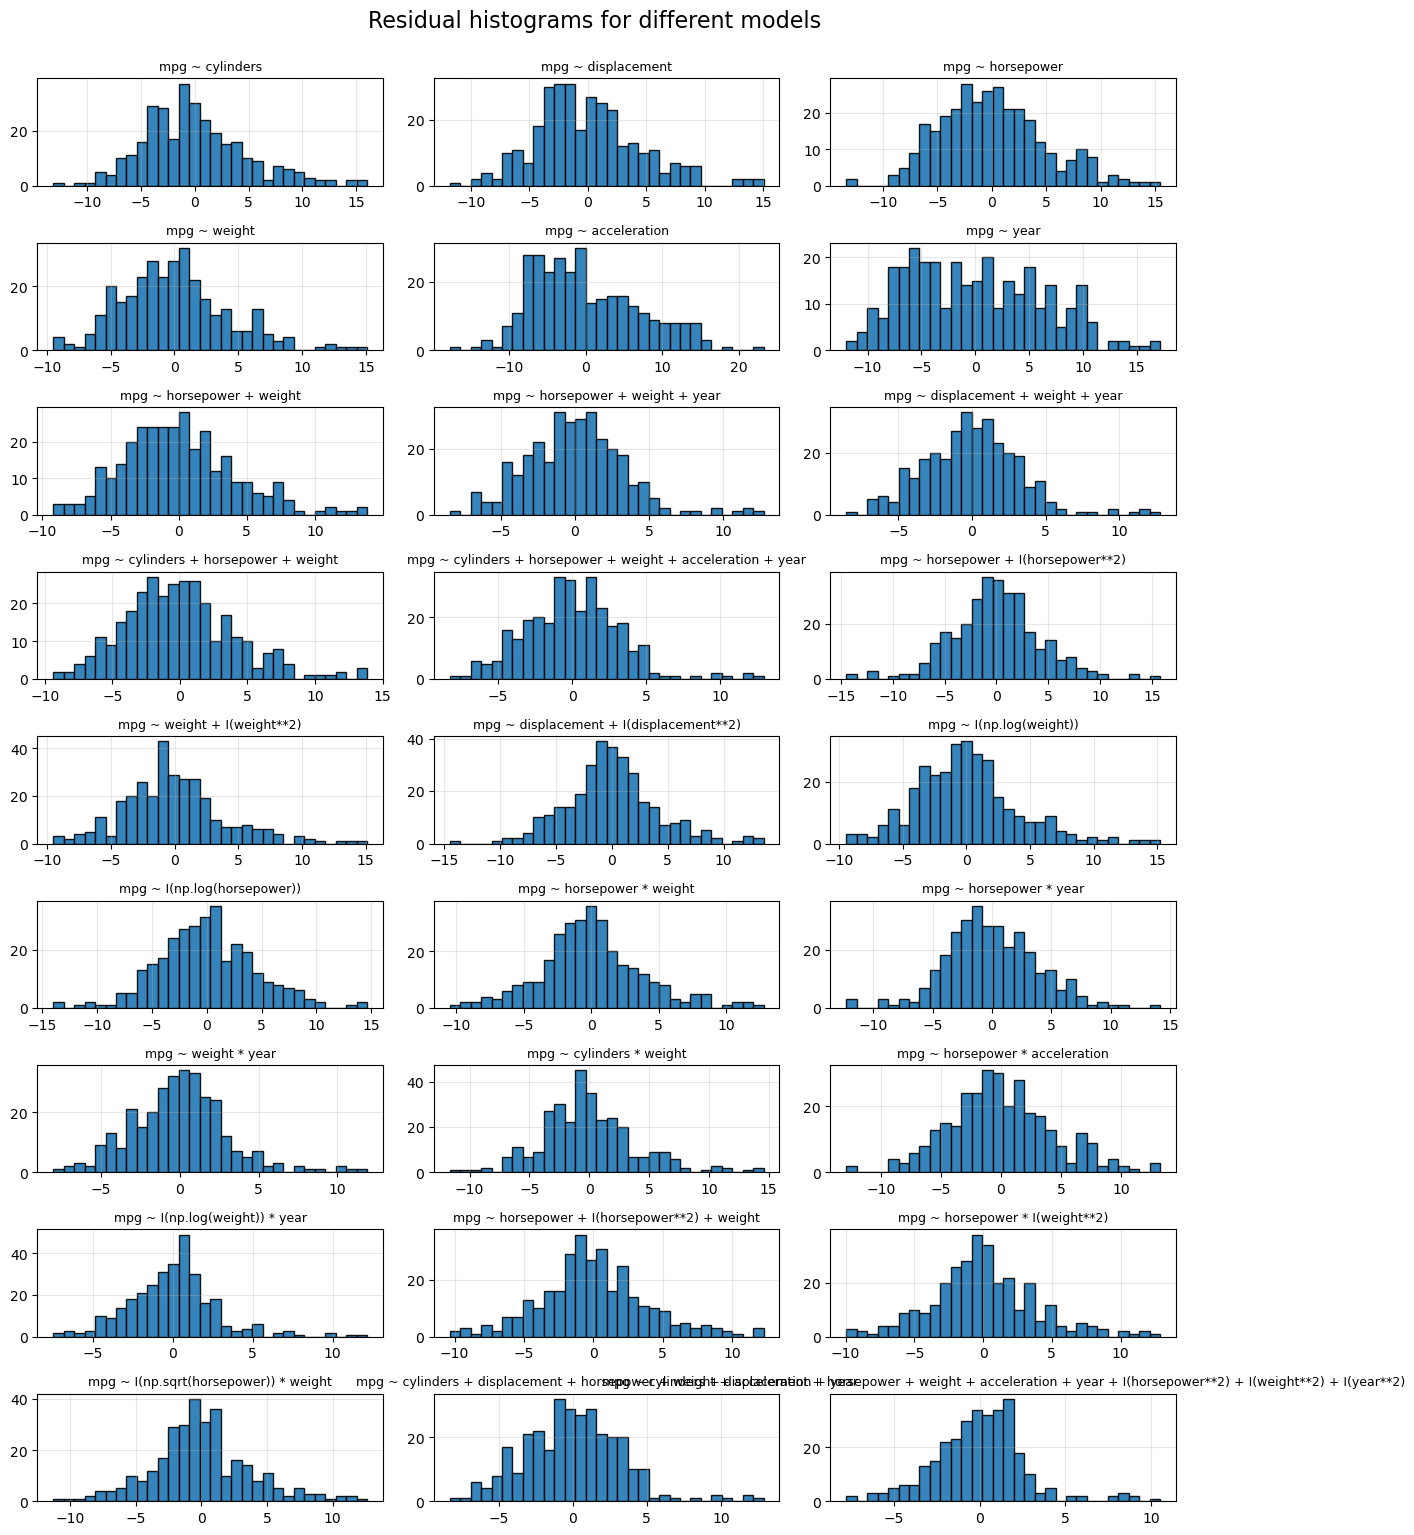

In [65]:
fig, axes = plt.subplots(11, 3, figsize=(12, 18))
axes = axes.flatten()

for i, formula in enumerate(models):
    ax = axes[i]
    ax.hist(results[i].resid, bins=30, edgecolor="black", alpha=0.9)
    
    ax.set_title(formula, fontsize=9)
    ax.grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
fig.suptitle("Residual histograms for different models", fontsize=16, y=1.02)
plt.show()
